# **Trabajo Parcial**

**Integrantes:**
- Angel Gabriel Diaz Chavez (u20221c424)

Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud

# Carga e inspeccion de datos

In [2]:
df = pd.read_csv('twitter_reddit_posts.csv', encoding='latin-1')
df.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53044 entries, 0 to 53043
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  53044 non-null  object
 1   statement   52681 non-null  object
 2   status      53042 non-null  object
dtypes: object(3)
memory usage: 1.2+ MB


In [4]:
df.shape

(53044, 3)

# Valores vacios o 0

In [5]:
df.isna().sum()

Unnamed: 0      0
statement     363
status          2
dtype: int64

In [6]:
(df == 0).sum()

Unnamed: 0    0
statement     0
status        0
dtype: int64

# Valores Unicos y Repetidos

In [7]:
valores_unicos = df['statement'].nunique()
print(f"Cantidad de frases únicas: {valores_unicos}")

filas_duplicadas = df['statement'].duplicated(keep='first').sum()
print(f"Cantidad de filas repetidas: {filas_duplicadas}")

if filas_duplicadas > 0:
    print("\n--- DETALLE DE LAS FRASES REPETIDAS ---")

    df_agrupado = df.groupby('statement').agg(
        Cantidad_de_apariciones=('statement', 'size'),
        Status_asociado=('status', lambda x: ', '.join(x.dropna().astype(str).unique()))
    ).reset_index()

    df_repetidos_todos = df_agrupado[df_agrupado['Cantidad_de_apariciones'] > 1]

    df_repetidos_todos = df_repetidos_todos.sort_values(by='Cantidad_de_apariciones', ascending=False)
    
    print(f"Hay un total de {len(df_repetidos_todos)} frases distintas que se están repitiendo.")
    print("\nMostrando el top 20 de las frases que más se repiten:")

    df_top_20 = df_repetidos_todos.head(20).copy()
    df_top_20.rename(columns={'statement': 'Frase (statement)'}, inplace=True)

    display(df_top_20[['Frase (statement)', 'Cantidad_de_apariciones', 'Status_asociado']])
    
else:
    print("\nEl dataset no tiene frases repetidas.")

Cantidad de frases únicas: 51070
Cantidad de filas repetidas: 1973

--- DETALLE DE LAS FRASES REPETIDAS ---
Hay un total de 1403 frases distintas que se están repitiendo.

Mostrando el top 20 de las frases que más se repiten:


,Frase (statement),Cantidad_de_apariciones,Status_asociado
49689,what do you mean?,22,Normal
50292,why not?,16,Normal
181,#NAME?,16,"Normal, Depression, Suicidal, Stress"
45175,ni-ki best boy,11,Normal
49732,what happened?,10,Normal
29974,Survey on Situational Stress and Music (18 and...,10,Stress
50274,why is that?,9,Normal
41584,i want to be dead ive been suicidal for year i...,8,Depression
35470,being border restricted victim day by day we g...,8,Depression
43930,like what?,7,Normal


--- ESTADÍSTICAS DE LONGITUD DE TEXTOS ---


count    53044.000000
mean       112.390449
std        163.438169
min          1.000000
25%         15.000000
50%         61.000000
75%        147.250000
max       6300.000000
Name: word_count, dtype: float64

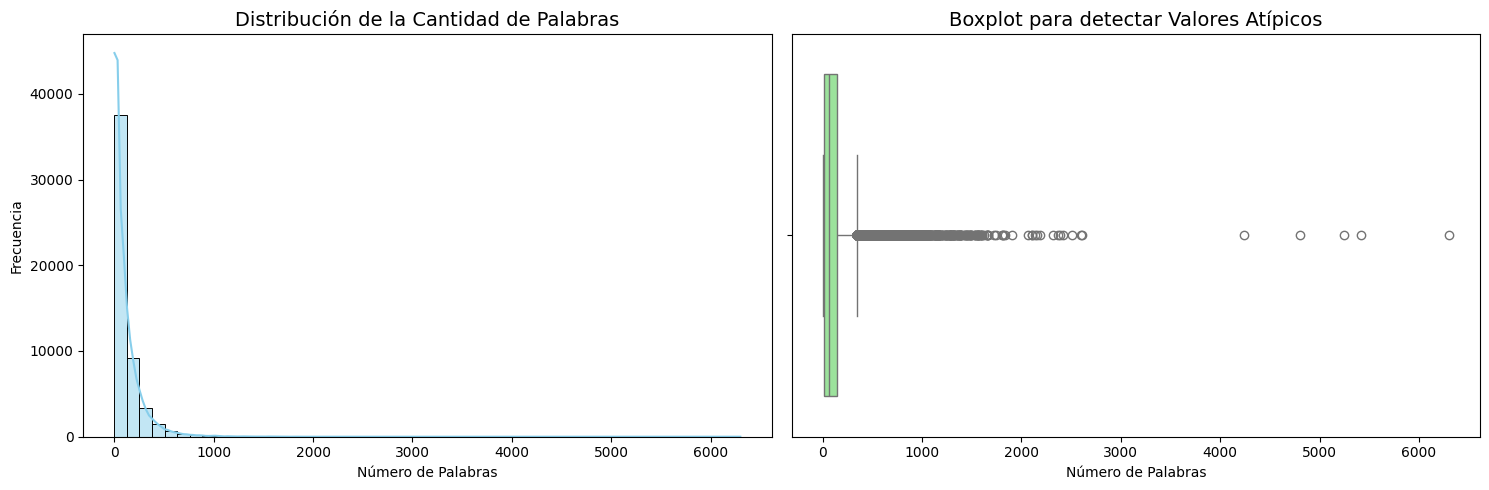


--- SUGERENCIA DE LÍMITES (PERCENTILES 1% y 99%) ---
El 1% de los textos tiene menos de: 1.0 palabras.
El 99% de los textos tiene menos de: 732.0 palabras.


In [8]:
df['word_count'] = df['statement'].apply(lambda x: len(str(x).split()))

print("--- ESTADÍSTICAS DE LONGITUD DE TEXTOS ---")
display(df['word_count'].describe())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma
sns.histplot(df['word_count'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de la Cantidad de Palabras', fontsize=14)
axes[0].set_xlabel('Número de Palabras')
axes[0].set_ylabel('Frecuencia')

# Boxplot
sns.boxplot(x=df['word_count'], ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot para detectar Valores Atípicos', fontsize=14)
axes[1].set_xlabel('Número de Palabras')

plt.tight_layout()
plt.show()

limite_inferior = df['word_count'].quantile(0.01) # El 1% más corto
limite_superior = df['word_count'].quantile(0.99) # El 1% más largo

print("\n--- SUGERENCIA DE LÍMITES (PERCENTILES 1% y 99%) ---")
print(f"El 1% de los textos tiene menos de: {limite_inferior} palabras.")
print(f"El 99% de los textos tiene menos de: {limite_superior} palabras.")

# Preprocesamiento

In [9]:
tamaño_original = df.shape[0]
print(f"Tamaño inicial del dataset: {tamaño_original} filas.\n")

df = df.dropna(subset=['statement'])
tamaño_sin_nulos = df.shape[0]
print(f"1. Filas tras eliminar nulos: {tamaño_sin_nulos} (Se borraron {tamaño_original - tamaño_sin_nulos})")


Tamaño inicial del dataset: 53044 filas.

1. Filas tras eliminar nulos: 52681 (Se borraron 363)


In [10]:
df = df.drop_duplicates(subset=['statement'], keep='first')
tamaño_sin_duplicados = df.shape[0]
print(f"2. Filas tras eliminar duplicados: {tamaño_sin_duplicados} (Se borraron {tamaño_sin_nulos - tamaño_sin_duplicados})")

2. Filas tras eliminar duplicados: 51070 (Se borraron 1611)


In [11]:
df['word_count'] = df['statement'].apply(lambda x: len(str(x).split()))

min_palabras = 4
max_palabras = 750

df = df[(df['word_count'] >= min_palabras) & (df['word_count'] <= max_palabras)].copy()
tamaño_final = df.shape[0]
print(f"3. Filas tras eliminar atípicos (longitud < {min_palabras} o > {max_palabras}): {tamaño_final} (Se borraron {tamaño_sin_duplicados - tamaño_final})")

print("\n--- PREPROCESAMIENTO ESTRUCTURAL COMPLETADO ---")
print(f"Total de filas eliminadas en esta fase: {tamaño_original - tamaño_final}")
print(f"Tamaño definitivo del dataset para entrenar: {tamaño_final} filas.")

3. Filas tras eliminar atípicos (longitud < 4 o > 750): 48990 (Se borraron 2080)

--- PREPROCESAMIENTO ESTRUCTURAL COMPLETADO ---
Total de filas eliminadas en esta fase: 4054
Tamaño definitivo del dataset para entrenar: 48990 filas.


Explicacion

**1. Eliminación de Valores Nulos (Missing Values)**

- Justificación Técnica: Los algoritmos y las técnicas de vectorización de texto (como TF-IDF, Word2Vec o representaciones densas) son estrictamente operaciones matemáticas. Un valor nulo o "NaN" no es un texto vacío, sino la ausencia de un objeto en la memoria, lo que imposibilita su conversión a un vector numérico y provocaría un error fatal de ejecución (ValueError) durante el entrenamiento.

- Decisión: Se eliminaron las filas con nulos en la columna objetivo (statement) para garantizar la integridad de las matrices de características.

**2. Eliminación de Registros Duplicados**

- Justificación Metodológica: En procesamiento de lenguaje natural, los modelos aprenden basándose en las frecuencias y co-ocurrencias de las palabras. Si un texto idéntico se repite cientos de veces (lo cual es común en redes sociales debido a bots, spam o retweets masivos), el modelo asumirá incorrectamente que los patrones de ese texto son universales.

- Decisión: Se eliminaron los duplicados exactos para evitar que el modelo memorice frases repetidas (Overfitting o sobreajuste), asegurando que aprenda a generalizar sobre una variedad real y diversa de expresiones de salud mental.

**3. Tratamiento de Valores Atípicos (Filtro por longitud de palabras)**

- Justificación para el Límite Inferior (Menos de 4 palabras): Textos extremadamente cortos (ej. "ok", "help me", "bad day") carecen de la densidad semántica necesaria. El algoritmo no tiene suficiente contexto lingüístico para descubrir características subyacentes que distingan un cuadro de Ansiedad de uno Bipolar, introduciendo ruido al modelo.

- Justificación para el Límite Superior (Más de 750 palabras): La presencia de textos infinitos (como la anomalía detectada de 6,300 palabras) genera matrices excesivamente grandes. Al pasar esto a la etapa de modelización, secuencias tan largas saturan rápidamente la memoria VRAM de la tarjeta gráfica, obligando a reducir el tamaño del batch a niveles ineficientes.

- Decisión: Al aislar el rango entre 4 y 750 palabras, se conservó el 99% de la información útil y representativa, garantizando eficiencia computacional y calidad semántica.

# *EDA*

C:\Users\agabr\AppData\Local\Temp\ipykernel_23888\2919230268.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='status', order=orden_clases, palette='viridis')


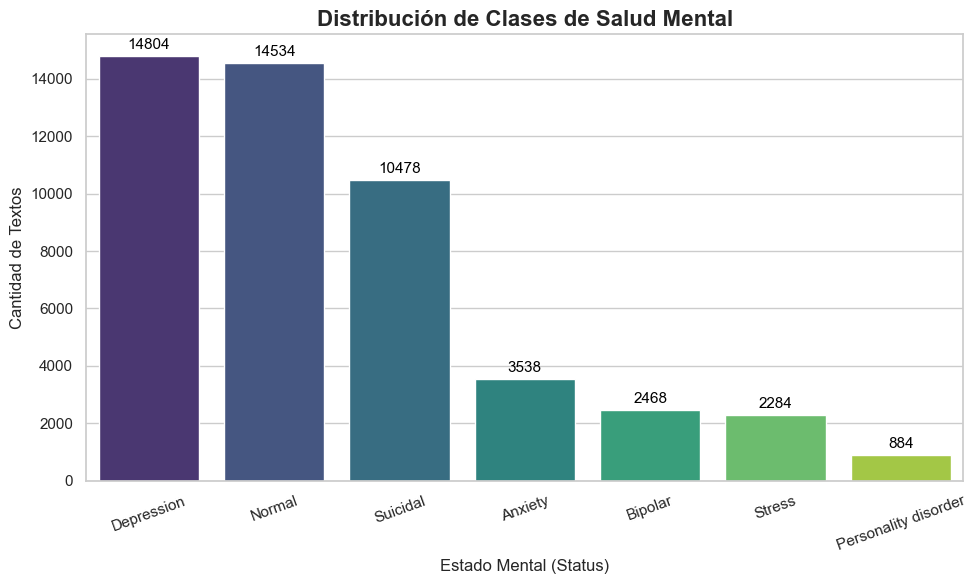

In [20]:
#Distribución de Clases (Balanceo del Target)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
# Obtenemos el orden de mayor a menor
orden_clases = df['status'].value_counts().index

# Generamos el gráfico de barras
ax = sns.countplot(data=df, x='status', order=orden_clases, palette='viridis')

plt.title('Distribución de Clases de Salud Mental', fontsize=16, fontweight='bold')
plt.xlabel('Estado Mental (Status)', fontsize=12)
plt.ylabel('Cantidad de Textos', fontsize=12)
plt.xticks(rotation=20)

# Añadimos los números exactos sobre cada barra para mayor claridad
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='baseline', fontsize=11, color='black', 
                xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

C:\Users\agabr\AppData\Local\Temp\ipykernel_23888\2529639275.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='status', y='word_count', order=orden_clases, palette='Set2')


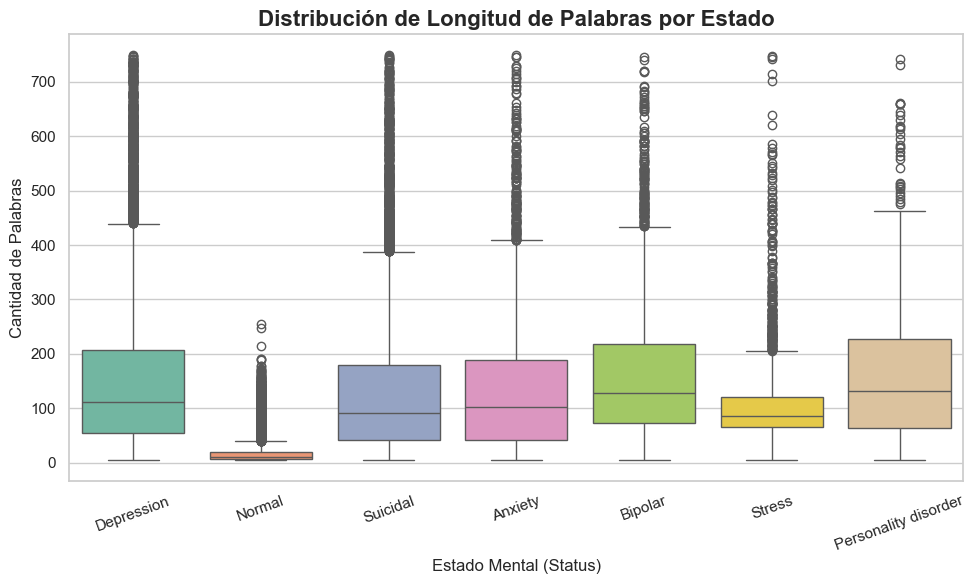

In [21]:
#Longitud del Texto por Estado Mental
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='status', y='word_count', order=orden_clases, palette='Set2')

plt.title('Distribución de Longitud de Palabras por Estado', fontsize=16, fontweight='bold')
plt.xlabel('Estado Mental (Status)', fontsize=12)
plt.ylabel('Cantidad de Palabras', fontsize=12)
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()